<div >
<img src = "../banner.jpg" />
</div>

<a target="_blank" href="https://colab.research.google.com/github/ignaciomsarmiento/BDML_2026_20/blob/main/Lecture05/Lecture_05_Ridge.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



# Regularization

## Predicting Wages

Our objective today is to construct a model of individual wages

$$
w = f(X) + u 
$$

where w is the  wage, and X is a matrix that includes potential explanatory variables/predictors. In this tutorial set, we will focus on a linear model of the form

\begin{align}
 ln(w) & = \beta_0 + \beta_1 X_1 + \dots + \beta_p X_p  + u 
\end{align}

were $ln(w)$ is the logarithm of the wage.

To illustrate I'm going to use a sample of the NLSY97. The NLSY97 is  a nationally representative sample of 8,984 men and women born during the years 1980 through 1984 and living in the United States at the time of the initial survey in 1997.  Participants were ages 12 to 16 as of December 31, 1996.  Interviews were conducted annually from 1997 to 2011 and biennially since then.  

Let's load the packages and the data set:

In [1]:
#install.packages("pacman") #for google colab

In [2]:
#packages
require("pacman")
p_load("tidyverse","stargazer")

nlsy <- read_csv('https://raw.githubusercontent.com/ignaciomsarmiento/datasets/main/nlsy97.csv')

nlsy <- nlsy  %>%   drop_na(educ) #drops NAs

Loading required package: pacman



Rows: 1266 Columns: 994


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (994): lnw_2016, educ, black, hispanic, other, exp, afqt, mom_educ, dad_...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


We want to construct a model that predicts well out of sample, and we have potentially 993 regressors. We are going to regularize this regression using the `glmnet` package.


## Glmnet

To apply a regularized model, we can use the `glmnet::glmnet()` function. `glmnet` solves the problem

$$
\min_{\beta_0,\beta} \frac{1}{N} \sum_{i=1}^{N} w_i l(y_i,\beta_0+\beta' x_i) + \lambda\left[(1-\alpha)\frac{1}{2}\|\beta\|_2^2 + \alpha \|\beta\|_1\right],
$$

where $l(y_i,\beta_0+\beta^T x_i)$ in the regression case is $\frac{1}{2}(y_i-\beta_0-\beta' x_i)^2$

The `alpha` parameter tells `glmnet` to perform a ridge (`alpha` = 0), lasso (`alpha` = 1), or elastic net (0 < `alpha` < 1) model. 

By default, `glmnet` will do two things that you should know:

1.  By default, `glmnet` automatically standardizes your features. If you standardize your predictors prior to glmnet you can turn this argument off with `standardize = FALSE`.

2. The regularization path is computed at a grid of values (on the log scale) for the regularization parameter $\lambda$. The algorithm is extremely fast!

`glmnet` has some drawbacks, the main one is that we need to specify the arguments in terms of matrices and vectors

`caret`, in contrast, streamlines the process of creating predictive models by providing a uniform interface for predictive models, which, among other things, allows for specifying formulas.

## Ridge

We first illustrate ridge regression, which can be fit using `glmnet()` with alpha = 0 and seeks to minimize

$$
\frac{1}{2n}\sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}    \right) ^ 2 + \lambda \frac{1}{2}\sum_{j=1}^{p} \beta_j^2 .
$$

Notice that the intercept is not penalized. Why?


Ridge penalizes the squares  of the coefficients. As a result, ridge shrinks coefficients toward zero, but not all the way.


To understand the mechanics, we are going to focus on a small subset of variables:

1. **educ (Education Level)**  
   - This typically refers to the respondent's **highest level of education completed**.  
   - It is measured in **years of schooling** 
 
2. **mom_educ (Mother’s Education Level)**

- This represents the highest level of education completed by the respondent’s mother.
- Like "educ," it can be measured in years of schooling 
  

In [3]:
p_load("glmnet")

#Vector that needs predicting
y <- nlsy$lnw_2016

# Matrix of predictors 
Xsmall <- as.matrix(nlsy  %>% select(educ,mom_educ))

Let's run the ridge regression (we need to set the parameter `alpha` to zero)

We solve:

$$
\min_{\beta_0,\beta_1,\beta_2} \frac{1}{2n} \sum_{i=1}^{n} \left( log(wage)_i - \beta_0 -  \beta_1 Educ_i - \beta_2 MomEduc_i   \right) ^ 2 + \lambda \frac{1}{2} \left(\beta_1^2+ \beta_2^2 \right)
$$

In [4]:
ridge1 <- glmnet(
  x = Xsmall,
  y = y,
  lambda=1,
  alpha = 0 #ridge
)

In [5]:
coef(ridge1)

3 x 1 sparse Matrix of class "dgCMatrix"
                    s0
(Intercept) 2.38973488
educ        0.03286252
mom_educ    0.01877242

Are these shrunken relative to OLS?

In [6]:
stargazer(lm(y~Xsmall),type="text")


                        Dependent variable:    
                    ---------------------------
                                 y             
-----------------------------------------------
Xsmalleduc                   0.070***          
                              (0.009)          
                                               
Xsmallmom_educ                0.021**          
                              (0.011)          
                                               
Constant                     1.827***          
                              (0.149)          
                                               
-----------------------------------------------
Observations                   1,266           
R2                             0.069           
Adjusted R2                    0.068           
Residual Std. Error      0.839 (df = 1263)     
F Statistic          47.094*** (df = 2; 1263)  
Note:               *p<0.1; **p<0.05; ***p<0.01


H.W. Why the intercepts are not equal? Tip: Think on how the intercept is computed.

### Regularization Paths

Let's see the regularization path, that shows how much the coefficients are penalized for different values of $\lambda$. 

In [7]:
ridge2 <- glmnet(
  x = Xsmall,
  y = y,
  alpha = 0 #ridge
)

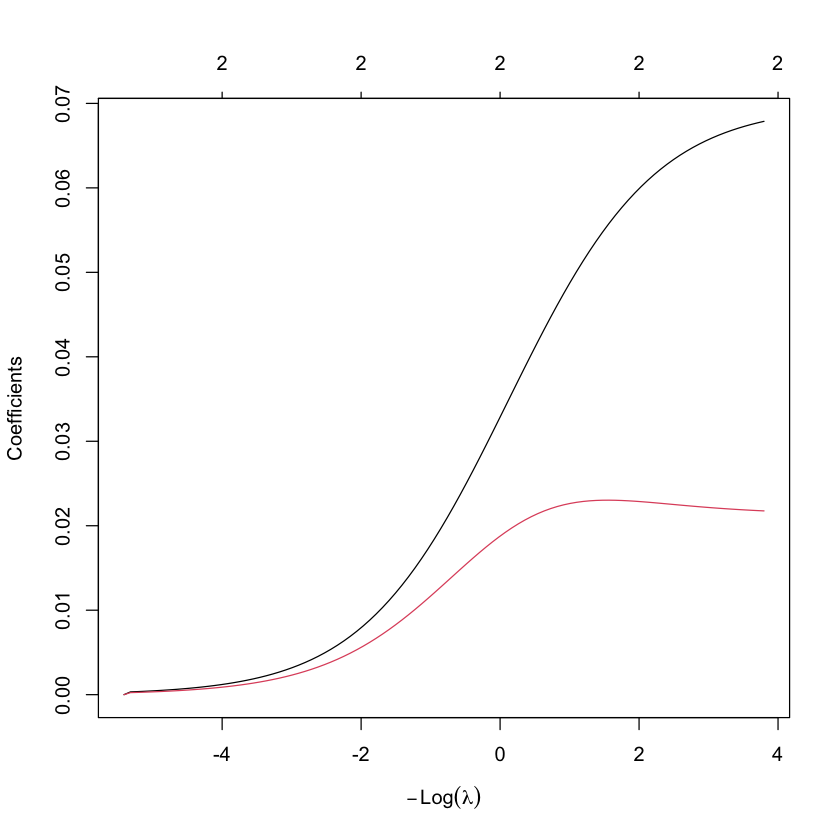

In [8]:
plot(ridge2, xvar = "lambda")

Notice none of the coefficients are forced to be zero, although they get close to it.

#### All the predictors

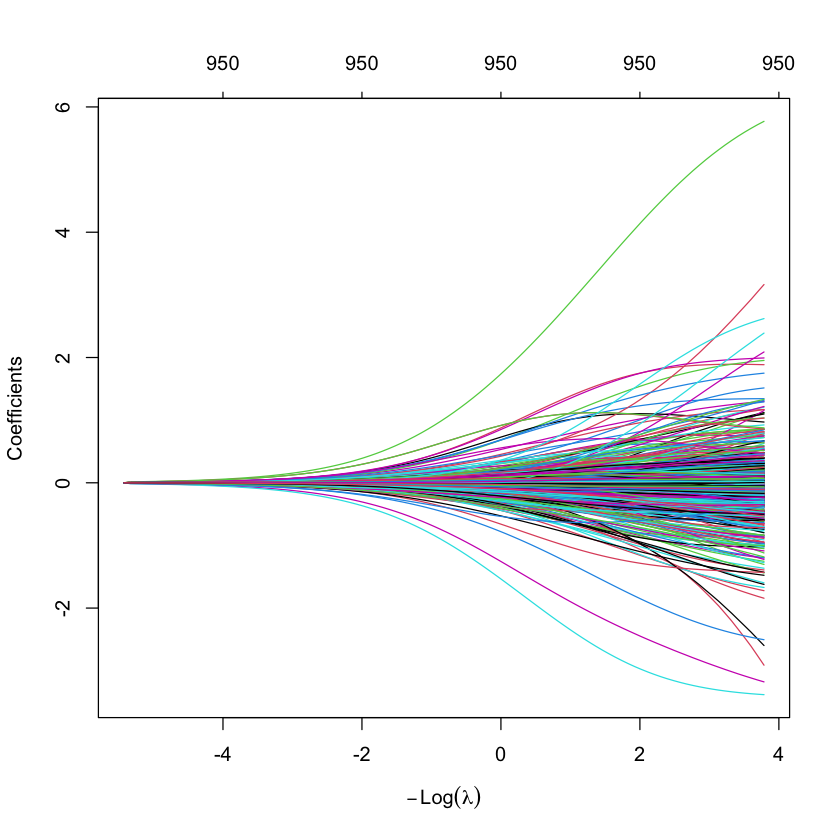

In [9]:
# Matrix of predictors (all but lnw_2016)
X <- as.matrix(nlsy  %>% select(-lnw_2016))

ridge_all <- glmnet(
  x = X,
  y = y,
  alpha = 0 #ridge
)

plot(ridge_all, xvar = "lambda")


The *regularization path*, which illustrates how the model’s coefficients change as we vary the regularization strength $\lambda$. 

- When $\lambda$ is large, the penalty on the size of the coefficients is strong, pushing most coefficients toward zero (or shrinking them substantially). This helps prevent overfitting by limiting how large the coefficients are.

- As $\lambda$ decreases, the penalty weakens. Coefficients that were previously shrunk toward zero may increase in magnitude if they improve the model’s fit to the data. Consequently, the model becomes more flexible and potentially more prone to overfitting.


### Scale Equivariance

Ridge penalizes $\sum_j \beta_j^2$, the size of the **coefficients**, not the size of the
predictors. But a coefficient is measured in the inverse units of its predictor, so the two move
together: rescale a predictor so its values are numerically **smaller**, and its coefficient becomes
correspondingly **larger**, and pays a **larger** penalty, for exactly the same underlying effect.

So the units matters, because it affects  how hard that variable gets shrunk. OLS is
immune to this; ridge is not. Before penalizing, we need to put every predictor on a common scale.


#### A Bit of intuition

Why does the scale matter for ridge but not for OLS? Write mother's education in decades instead of years:

$$
\widetilde{MomEduc}_i = \frac{MomEduc_i}{10}
$$

This is the *same model*, only renamed units:

$$
log(wage)_i = \beta_0 + \beta_1 Educ_i + \tilde{\beta}_2 \widetilde{MomEduc}_i + u_i,
\qquad \text{where } \tilde{\beta}_2 = 10\,\beta_2
$$

Dividing the **variable** by 10 **multiplies** the coefficient by 10  so that
$\tilde{\beta}_2 \widetilde{MomEduc}_i = \beta_2 MomEduc_i$. Fitted values, residuals and RSS are all
identical. OLS sees no difference whatsoever, and that is exactly why OLS is scale equivariant.

The **penalty** does see a difference. Ridge charges $\lambda$ times the square of whatever coefficient
it happens to be estimating:

| units of `mom_educ` | penalty paid for the *same* underlying effect |
|---|---|
| years | $\lambda\,(\beta_1^2 + \beta_2^2)$ |
| decades | $\lambda\,(\beta_1^2 + \tilde{\beta}_2^2) \;=\; \lambda\,(\beta_1^2 + 100\,\beta_2^2)$ |

Same data, same $\lambda$, same fit available, but in decades the mother's-education coefficient costs
**100 times more**. Ridge responds by shrinking it much harder.

> **The coarser the units, the larger the coefficient, and the heavier the shrinkage.**

Note what this means: a purely cosmetic change of units changes the answer.


#### The fix: `standardize = TRUE`

The algebra above says the problem is that the penalty $\lambda\sum_j \beta_j^2$ is **not scale-free**. `glmnet` handles it by standardizing every column internally (mean 0, sd 1) before penalizing, and reporting the coefficients back on the original scale.

To see it we have to hold $\lambda$ **fixed** and change *only* the scale, otherwise we cannot tell shrinkage apart from rescaling.

In [10]:
# Build both scalings explicitly, so the only thing that differs between the
# two fits below is the unit of mom_educ -- lambda is held fixed.
X_anios <- as.matrix(nlsy %>% select(educ, mom_educ))
X_dec   <- X_anios
X_dec[, 2] <- X_dec[, 2] / 10   # mom_educ in decades instead of years

lambda_fix <- 20  # same lambda in every fit below


In [11]:
# (a) standardize = FALSE -> the penalty sees the raw units
a_anios <- coef(glmnet(X_anios, y, alpha = 0, lambda = lambda_fix, standardize = FALSE))[3]
a_dec   <- coef(glmnet(X_dec,   y, alpha = 0, lambda = lambda_fix, standardize = FALSE))[3]

c(anios = a_anios, dec_a_anios = a_dec / 10, ratio = (a_dec / 10) / a_anios)

anios  dec_a_anios        ratio 
0.0094322368 0.0001165001 0.0123512662

In [12]:
# (b) standardize = TRUE -> glmnet standardizes internally: scale-invariant
b_anios <- coef(glmnet(X_anios, y, alpha = 0, lambda = lambda_fix, standardize = TRUE))[3]
b_dec   <- coef(glmnet(X_dec,   y, alpha = 0, lambda = lambda_fix, standardize = TRUE))[3]

c(anios = b_anios, dec_a_anios = b_dec / 10, ratio = (b_dec / 10) / b_anios)

anios dec_a_anios       ratio 
0.002318445 0.002318445 1.000000000

In [13]:
# (c) OLS, for reference: equivariant with or without rescaling
c(anios       = unname(lm(y ~ X_anios)$coefficients[3]),
  dec_a_anios = unname(lm(y ~ X_dec)$coefficients[3] / 10))

anios dec_a_anios 
 0.02133815  0.02133815

In [14]:
# (d) How hard is each parametrization actually shrunk? Compare each ridge fit
#     to ITS OWN OLS coefficient, so the units cancel out.
sh_anios <- a_anios / unname(lm(y ~ X_anios)$coefficients[3])
sh_dec   <- a_dec   / unname(lm(y ~ X_dec)$coefficients[3])

round(c(`ridge/OLS, years`   = sh_anios,
        `ridge/OLS, decades` = sh_dec,
        `times more shrunk`  = sh_anios / sh_dec), 4)


ridge/OLS, years ridge/OLS, decades  times more shrunk 
            0.4420             0.0055            80.9634

What we see:

- `standardize = FALSE` $\rightarrow$ ratio $\approx 0.012$. Putting `mom_educ` in decades shrank
  its coefficient by a factor of about **80**. Same data, same $\lambda$, different answer.
- `standardize = TRUE` $\rightarrow$ ratio **exactly 1**. The penalty now acts on standardized
  coefficients, so the units of `mom_educ` stop mattering.
- OLS $\rightarrow$ identical under both scalings. There is no penalty to distort, so the problem
  in (a) is a property of the **penalty**, not of the regression.

This is why `glmnet` standardizes by default.


### Penalty selection

Now we need to discuss how we select $\lambda$: 

- Making sure that we have **zero bias** within the sample creates **out-of-sample problems**: **Bias-Variance trade-off**.

- We make this trade-off **empirically**.

    \begin{align}
            \min_{\beta} L(\beta) = \sum_{i=1}^n (y_i-\beta_0 - x_{i1}\beta_1 - \dots - x_{ip}\beta_p)^2 + \lambda \sum_{j=1}^p R(\beta_j)
    \end{align}

- **$\lambda$ is the price for this trade-off**.

How do we choose  $\lambda$?  $\rightarrow$  **Cross-validation**.


1. Initialization: Initially, we select a range of $\lambda$ values. These could be chosen based on prior knowledge, heuristics, or a predefined range.

2. Iteration Over Folds:

    - Fold 1 as Validation: We train the Ridge regression model on Folds 2-5 (combining them to form the training set) and validate the model on Fold 1. We record the MSE  for each $\lambda$  value.
    - Fold 2 as Validation: Next, we train on Folds 1, 3-5 and validate on Fold 2, recording the MSE  for each $\lambda$  value.
    - We repeat this process, training on four folds and validating on the remaining one, cycling through until each fold has served as the validation set.
  

<div>
<img src="https://raw.githubusercontent.com/ignaciomsarmiento/BDML_2026_20/main/Lecture04/figs_notebook_SS04/fold.png" width="500"/>
</div>


- Error Aggregation: For each $\lambda$   value, we average the MSE across all five folds. 

- Selection of $\lambda$ : We select the $\lambda$  value that yields the lowest MSE. This is the value that we expect to generalize best to unseen data.

Let's do it on all the predictors:

In [15]:
#Vector that needs predicting
y <- nlsy$lnw_2016

# Matrix of predictors (all but lnw_2016)
X <- as.matrix(nlsy  %>% select(-lnw_2016))


#### 1. Initialization: Initially, we select a range of $\lambda$ values. 

In [16]:


# Define lambda sequence
lambda_seq <- 10^seq(4, -2, length = 100)
lambda_seq


[1] 1.000000e+04 8.697490e+03 7.564633e+03 6.579332e+03 5.722368e+03
  [6] 4.977024e+03 4.328761e+03 3.764936e+03 3.274549e+03 2.848036e+03
 [11] 2.477076e+03 2.154435e+03 1.873817e+03 1.629751e+03 1.417474e+03
 [16] 1.232847e+03 1.072267e+03 9.326033e+02 8.111308e+02 7.054802e+02
 [21] 6.135907e+02 5.336699e+02 4.641589e+02 4.037017e+02 3.511192e+02
 [26] 3.053856e+02 2.656088e+02 2.310130e+02 2.009233e+02 1.747528e+02
 [31] 1.519911e+02 1.321941e+02 1.149757e+02 1.000000e+02 8.697490e+01
 [36] 7.564633e+01 6.579332e+01 5.722368e+01 4.977024e+01 4.328761e+01
 [41] 3.764936e+01 3.274549e+01 2.848036e+01 2.477076e+01 2.154435e+01
 [46] 1.873817e+01 1.629751e+01 1.417474e+01 1.232847e+01 1.072267e+01
 [51] 9.326033e+00 8.111308e+00 7.054802e+00 6.135907e+00 5.336699e+00
 [56] 4.641589e+00 4.037017e+00 3.511192e+00 3.053856e+00 2.656088e+00
 [61] 2.310130e+00 2.009233e+00 1.747528e+00 1.519911e+00 1.321941e+00
 [66] 1.149757e+00 1.000000e+00 8.697490e-01 7.564633e-01 6.579332e-01
 [71] 5.722368e-01 4.977024e-01 4.328761e-01 3.764936e-01 3.274549e-01
 [76] 2.848036e-01 2.477076e-01 2.154435e-01 1.873817e-01 1.629751e-01
 [81] 1.417474e-01 1.232847e-01 1.072267e-01 9.326033e-02 8.111308e-02
 [86] 7.054802e-02 6.135907e-02 5.336699e-02 4.641589e-02 4.037017e-02
 [91] 3.511192e-02 3.053856e-02 2.656088e-02 2.310130e-02 2.009233e-02
 [96] 1.747528e-02 1.519911e-02 1.321941e-02 1.149757e-02 1.000000e-02

#### 2. Iteration Over Folds:

##### Create the folds

In [17]:
K <- 5  # 5-fold cross-validation

# Create folds
set.seed(123)  # Ensure reproducibility
folds <- sample(rep(1:K, length.out = length(y)))  # Assign randomly 1-5 to each observation.
folds 

[1] 5 3 4 1 5 3 2 3 3 5 2 4 1 5 3 3 2 5 1 4 1 2 3 5 3 4 2 4 5 5 2 2 3 1 4 4 1
  [38] 2 1 2 3 1 2 4 3 4 2 1 1 5 1 3 5 4 2 1 3 3 3 2 4 4 1 3 4 5 4 3 3 1 2 3 1 1
  [75] 1 4 2 3 5 2 4 4 5 5 3 1 5 5 1 2 2 1 4 1 3 3 2 2 5 4 2 1 1 2 5 5 1 4 1 4 5
 [112] 4 2 1 2 5 4 2 5 1 5 5 1 4 4 4 4 2 2 1 1 4 2 4 2 4 3 2 1 5 5 2 2 1 3 3 5 1
 [149] 5 2 3 5 5 5 1 3 1 3 4 5 5 3 2 2 5 5 4 4 4 5 2 3 5 1 2 2 2 4 5 2 1 2 3 3 3
 [186] 2 2 3 4 1 3 4 3 1 2 5 5 3 3 3 4 2 3 4 2 1 2 3 3 2 3 2 1 5 1 4 1 1 4 5 3 4
 [223] 5 1 2 3 4 5 3 2 5 4 5 4 1 2 2 2 2 5 5 2 1 3 2 5 2 3 3 1 1 5 4 1 4 3 5 4 1
 [260] 5 1 3 5 2 5 3 5 3 2 4 1 1 3 2 4 2 3 4 5 2 1 2 5 4 4 5 3 4 1 1 2 1 5 4 4 3
 [297] 1 5 1 1 4 5 2 3 1 5 5 3 2 4 2 5 4 2 4 2 2 4 2 2 2 1 5 4 2 4 1 5 4 4 5 5 4
 [334] 3 1 5 3 1 5 4 5 1 2 1 5 2 4 2 5 5 3 1 1 1 1 3 4 2 5 2 1 2 1 4 3 4 1 2 2 4
 [371] 2 1 4 2 5 1 5 3 5 2 2 4 3 2 2 2 5 3 3 5 5 3 3 1 3 4 4 3 2 5 1 3 4 4 5 4 3
 [408] 4 5 4 3 3 1 3 4 4 1 5 4 1 3 3 4 2 3 1 4 2 3 2 2 5 1 5 3 1 4 4 4 2 4 3 2 1
 [445] 5 4 2 1 1 3 3 5 4 4 1 4 5 3 1 5 1 5 5 4 1 1 2 4 3 4 4 1 2 2 1 4 5 1 5 4 5
 [482] 2 3 3 3 1 5 5 1 5 3 5 2 2 1 3 2 3 3 3 5 5 5 5 4 4 2 1 5 1 5 3 2 3 1 2 4 4
 [519] 4 4 3 1 3 4 4 4 4 4 1 2 4 2 4 5 3 5 4 3 3 4 5 2 4 4 5 2 4 5 4 3 4 2 1 2 5
 [556] 2 1 2 2 3 5 1 4 2 5 2 1 1 3 3 1 2 5 1 1 5 2 4 5 4 4 1 3 2 4 3 4 4 2 2 3 3
 [593] 1 5 1 5 5 2 5 2 2 1 2 3 2 1 5 4 2 1 1 2 5 4 1 2 2 1 2 1 4 3 3 5 1 3 2 2 1
 [630] 1 2 2 3 3 5 5 5 2 1 1 1 1 3 1 5 5 2 2 2 2 4 1 3 2 3 1 4 2 3 5 1 4 2 1 3 4
 [667] 5 2 1 3 4 5 2 3 5 5 5 4 2 5 2 1 5 1 3 4 3 3 4 5 3 3 1 4 5 1 5 4 3 4 4 3 5
 [704] 2 3 1 1 4 5 5 4 4 2 2 5 5 4 2 2 1 1 3 4 5 2 1 5 5 3 4 5 5 5 2 5 4 3 1 1 3
 [741] 1 5 5 1 1 5 3 1 4 5 3 5 3 3 1 5 3 2 1 1 4 3 1 5 3 1 3 1 2 1 4 4 2 4 4 2 2
 [778] 5 2 5 4 2 5 5 4 2 5 4 4 4 2 1 1 5 1 4 3 2 5 5 3 1 1 3 5 5 2 2 1 4 2 4 4 3
 [815] 1 4 3 5 5 3 4 4 1 3 2 3 2 5 5 1 5 5 1 4 1 2 2 2 3 2 3 3 2 1 3 2 3 5 2 4 5
 [852] 4 3 2 3 1 4 3 5 3 1 3 1 2 5 1 1 2 3 2 3 5 5 2 1 5 4 2 1 4 1 4 3 5 3 5 3 4
 [889] 1 1 3 4 3 1 5 2 1 5 1 2 2 2 3 1 5 1 3 5 5 2 3 4 2 1 2 4 5 5 1 5 4 1 3 3 3
 [926] 4 3 1 2 5 5 3 1 5 3 4 3 5 3 2 4 3 3 3 5 3 5 5 1 4 1 5 5 3 3 2 3 4 2 3 1 4
 [963] 1 3 2 5 2 3 5 3 5 1 2 5 3 3 4 3 1 4 3 5 4 4 1 3 5 1 1 4 2 5 1 4 2 2 1 5 2
[1000] 2 1 1 3 1 4 4 5 1 1 2 5 2 3 1 1 4 1 3 1 1 3 2 4 3 1 2 2 5 4 4 1 3 4 5 2 4
[1037] 3 5 4 2 2 1 4 4 5 5 2 2 3 5 2 2 4 3 2 3 4 3 4 5 5 3 4 3 3 4 5 1 4 3 3 3 2
[1074] 2 1 1 4 4 2 5 3 1 4 2 3 5 4 5 2 5 4 4 2 4 2 2 3 5 3 5 3 5 2 5 5 2 4 1 4 3
[1111] 2 3 4 1 1 3 2 4 3 4 4 3 3 1 3 5 3 5 3 4 2 2 3 2 3 2 4 2 3 5 1 1 2 2 4 3 1
[1148] 5 2 3 4 4 1 5 5 4 1 4 4 4 2 4 4 1 1 3 1 1 4 4 5 5 4 1 1 3 1 2 3 5 2 2 1 1
[1185] 1 4 5 5 2 4 4 5 1 3 1 4 4 3 4 3 5 1 3 5 3 5 2 2 1 1 3 4 4 1 2 3 3 2 4 4 4
[1222] 5 2 5 2 2 4 3 3 3 5 3 4 3 1 3 3 3 4 3 1 1 1 1 5 1 2 4 1 2 5 1 2 4 5 4 1 5
[1259] 1 5 1 1 3 5 4 2

# Prepare to loop

In [18]:
# Store errors
cv_errors <- matrix(NA, nrow = length(lambda_seq), ncol = K)

# Loop over folds
for (k in 1:K) {

  test_idx <- which(folds == k) # Extract test indices for this fold
  
  # Training and testing folds
  X_train <- X[-test_idx, , drop = FALSE]  # Drop = FALSE prevents dimension reduction issues
  y_train <- y[-test_idx]
  X_test <- X[test_idx, , drop = FALSE]
  y_test <- y[test_idx]
  
  # Fit ridge regression for all lambdas (100 because that is the sequence we specified)
  ridge_model <- glmnet(X_train, y_train, alpha = 0, lambda = lambda_seq)
  
  # Predict on test set for each lambda
  y_pred <- predict(ridge_model, newx = X_test)
  
  # Compute MSE for each lambda
  cv_errors[, k] <- colMeans((y_test - y_pred)^2)
}


In [19]:
cv_errors

0.8137161,0.7506463,0.6940592,0.8088003,0.7138503
0.8136976,0.7506204,0.6940428,0.8087689,0.7138164
0.8136762,0.7505906,0.6940239,0.8087328,0.7137773
0.8136517,0.7505563,0.6940022,0.8086913,0.7137324
0.8136235,0.7505169,0.6939772,0.8086436,0.7136808
0.8135912,0.7504717,0.6939486,0.8085888,0.7136215
0.8135540,0.7504197,0.6939157,0.8085259,0.7135535
0.8135115,0.7503601,0.6938780,0.8084536,0.7134753
0.8134626,0.7502917,0.6938348,0.8083706,0.7133857
0.8134066,0.7502131,0.6937851,0.8082754,0.7132828
0.8133423,0.7501230,0.6937282,0.8081661,0.7131648


##### Error Aggregation: For each $\lambda$   value, we average the MSE across all five folds. 

In [20]:


# Average errors across folds
cv_mse <- rowMeans(cv_errors)

cv_mse

[1] 0.7562144 0.7561892 0.7561601 0.7561268 0.7560884 0.7560443 0.7559938
  [8] 0.7559357 0.7558691 0.7557926 0.7557049 0.7556043 0.7554890 0.7553569
 [15] 0.7552057 0.7550326 0.7548347 0.7546084 0.7543502 0.7540556 0.7537200
 [22] 0.7533383 0.7529046 0.7524128 0.7518562 0.7512278 0.7505199 0.7497249
 [29] 0.7488349 0.7478422 0.7467396 0.7455204 0.7441792 0.7427122 0.7411312
 [36] 0.7394973 0.7377127 0.7357833 0.7337537 0.7316396 0.7294609 0.7272417
 [43] 0.7250100 0.7227971 0.7206375 0.7185699 0.7166236 0.7148477 0.7132888
 [50] 0.7119880 0.7109918 0.7103493 0.7101127 0.7103378 0.7110844 0.7124171
 [57] 0.7144049 0.7171209 0.7206412 0.7250443 0.7304096 0.7368171 0.7443454
 [64] 0.7530712 0.7630678 0.7743839 0.7871189 0.8012968 0.8169994 0.8342594
 [71] 0.8530856 0.8735416 0.8956201 0.9193768 0.9447649 0.9717899 1.0004733
 [78] 1.0307794 1.0626525 1.0960581 1.1310122 1.1674295 1.2052008 1.2442873
 [85] 1.2845749 1.3260723 1.3684626 1.4116902 1.4558151 1.5004836 1.5455866
 [92] 1.5908851 1.6364925 1.6816575 1.7267244 1.7712209 1.8148929 1.8575471
 [99] 1.8990318 1.9393394

##### Selection of $\lambda$ : We select the $\lambda$  value that yields the lowest MSE. This is the value that we expect to generalize best to unseen data.

In [21]:
# Optimal lambda (minimizing the cross-validation error)
lambda_opt <- lambda_seq[which.min(cv_mse)]
# Print optimal lambda
print(lambda_opt)


[1] 7.054802


##### Train final model with optimal lambda

In [22]:
final_model <- glmnet(X, y, alpha = 0, lambda = lambda_opt)

#### Easier way, use cv.glmnet 
(even easier, caret -> TA session)

In [23]:
# Cross-validation using cv.glmnet with the same folds
# set.seed(123)  # Redundant here: foldid = folds fixes the partition, and folds was
#                # already drawn under set.seed(123) above, so cv.glmnet draws nothing.
#                # Uncomment if you drop foldid and let cv.glmnet build the folds (nfolds).
cv_ridge <- cv.glmnet(X, y, alpha = 0, lambda = lambda_seq, foldid = folds)
# foldid: an optional vector of values between 1 and nfolds identifying what fold each observation is in

In [24]:
# Optimal lambda from cv.glmnet
lambda_opt_glmnet <- cv_ridge$lambda.min
print(lambda_opt_glmnet)

[1] 7.054802


In [25]:
cv_ridge


Call:  cv.glmnet(x = X, y = y, lambda = lambda_seq, foldid = folds,      alpha = 0) 

Measure: Mean-Squared Error 

    Lambda Index Measure      SE Nonzero
min   7.05    53  0.7102 0.02515     950
1se  49.77    39  0.7338 0.02420     950

We can plot the MSE for each $\lambda$:

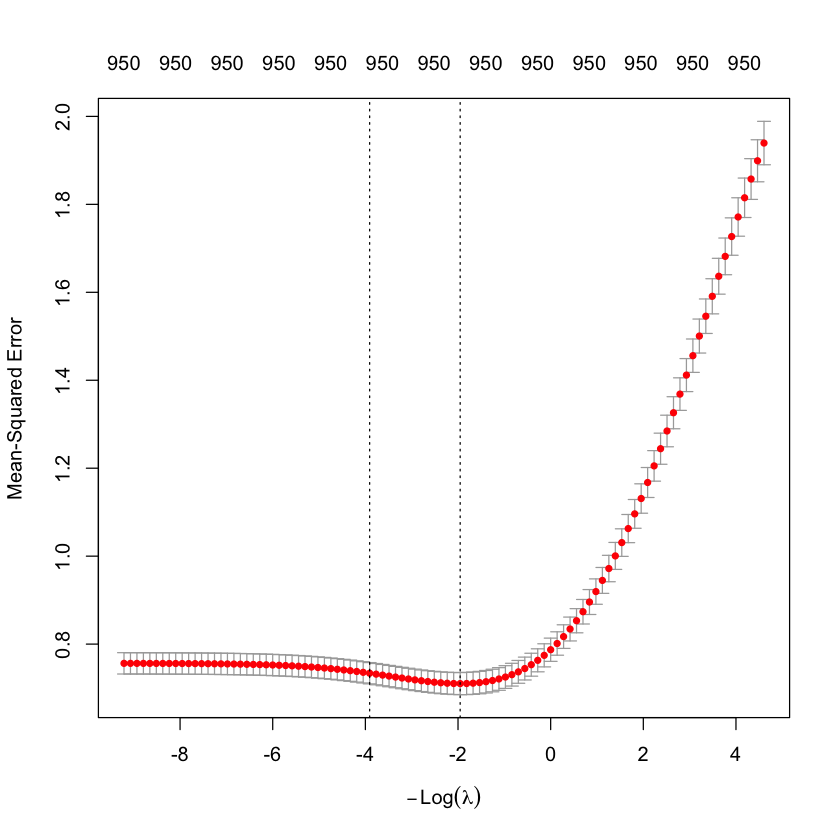

In [26]:
plot(cv_ridge)

This plots the cross-validation curve (red dotted line) along with upper and lower standard deviation curves
along the $\lambda$ sequence (error bars). 

Two special values along the $\lambda$ sequence are indicated by the vertical dotted lines:
 - lambda.min is the value of $\lambda$ that gives minimum mean cross-validated error, while 
 - lambda.1se is the value of $\lambda$ that gives the most regularized model such that the cross-validated error is within one standard error of the minimum.

We can use the following code to get the value of `lambda.min` 

In [27]:
cv_ridge$lambda.min

[1] 7.054802

In [28]:
log(cv_ridge$lambda.min)

[1] 1.953709

and the model coefficients at that value of $\lambda$:

In [29]:
head(coef(cv_ridge, s = "lambda.min"))

6 x 1 sparse Matrix of class "dgCMatrix"
              lambda.min
(Intercept)  2.954717563
educ         0.004829033
black       -0.025465346
hispanic     0.006616148
other       -0.033816794
exp         -0.003777411

In practice, the 1SE rule is sometimes used because some studies found that models chosen by $\lambda_{1SE}$ **tend to perform better on test data** than those chosen by $\lambda_{\min}$ (Hastie et al., *The Elements of Statistical Learning*).

### Does regularizing actually predict better out of sample?

Cross-validation picked $\lambda$, but it never answered the question this whole lecture is about: **is the regularized model actually better out of sample?** The CV loop evaluates on held-out *folds*, which is the right way to choose $\lambda$ — it is not a final verdict on the model.

For that we need data the model has never seen, and we need a competitor. This is the **split-first workflow from the slides**: hold out a test set, choose $\lambda$ by cross-validation inside the training sample only, and touch the test set once, at the end.

In [30]:
set.seed(123)

n   <- nrow(X)
idx <- sample(n, size = floor(0.7 * n))   # 70% train / 30% test

X_train <- X[idx, ];  y_train <- y[idx]
X_test  <- X[-idx, ]; y_test  <- y[-idx]

c(n_train = nrow(X_train), n_test = nrow(X_test), p = ncol(X_train))

n_train  n_test       p 
    886     380     993

Look at those numbers: $n_{train} = 886$ but $p = 993$. **We have more predictors than observations**, so $X'X$ is singular and OLS is not identified.

`lm()` will not stop us. It silently drops the predictors it cannot identify and returns `NA` for them:

In [31]:
ols_all <- lm(y_train ~ X_train)

sum(is.na(coef(ols_all)))   # coefficients R could not identify

[1] 317

In [32]:
# To predict we set the dropped coefficients to zero, i.e. we use the reduced-rank fit
b_ols <- coef(ols_all)
b_ols[is.na(b_ols)] <- 0

pred_ols <- cbind(1, X_test) %*% b_ols
mse_ols  <- mean((y_test - pred_ols)^2)
mse_ols

[1] 11.11764

Now Ridge. Note that $\lambda$ is chosen by cross-validation **inside the training set**, the test set is not touched until the final evaluation.

In [33]:
set.seed(123)
cv_ridge_tr <- cv.glmnet(X_train, y_train, alpha = 0)

mse_ridge_min <- mean((y_test - predict(cv_ridge_tr, newx = X_test, s = "lambda.min"))^2)
mse_ridge_1se <- mean((y_test - predict(cv_ridge_tr, newx = X_test, s = "lambda.1se"))^2)

c(lambda.min = cv_ridge_tr$lambda.min, lambda.1se = cv_ridge_tr$lambda.1se)

lambda.min lambda.1se 
  8.662915 195.523700

In [34]:
# Benchmark: predict mean(y_train) for everybody, ignoring all 993 predictors
mse_media <- mean((y_test - mean(y_train))^2)

round(c(`mean(y_train)`    = mse_media,
        `OLS (p > n)`      = mse_ols,
        `Ridge lambda.min` = mse_ridge_min,
        `Ridge lambda.1se` = mse_ridge_1se), 4)

mean(y_train)      OLS (p > n) Ridge lambda.min Ridge lambda.1se 
          0.7764          11.1176           0.7097           0.7764

### Putting it all together

| model | test MSE |
|---|---|
| predict `mean(y_train)` | 0.7764 |
| **OLS**, all 993 predictors | **11.1176** |
| **Ridge**, `lambda.min` | **0.7097** |
| Ridge, `lambda.1se` | 0.7764 |

- **OLS is about 16x worse than Ridge**, and worse than ignoring every predictor and guessing the mean. With $p > n$ it drives the in-sample error toward zero on the dimensions it can span, and its variance out of sample explodes. This is overfitting...
- **Ridge at `lambda.min` is the only model that beats the mean.** The penalty buys a little bias and is repaid with a large drop in variance. That is the bias-variance trade-off...
- **Ridge at `lambda.1se` lands exactly on the mean.** Here $\lambda_{1SE} = 195.5$ shrinks the coefficients so hard that the model predicts almost a constant. The 1SE rule is conservative; whether it helps is an empirical question...

Always remember the goal **predicting well out of sample**.